# Identical Summary Statistics Hide Very Different Data Patterns

## Task 1 — Why We Visualize (`datasaurus.csv`)

This notebook analyzes the 13 Datasaurus datasets to demonstrate why numerical summary statistics should be complemented by visualization.

**Lecture chart rules used in this notebook:**
- The chart title states the finding, rather than merely naming the axes.
- Scatterplots use the natural data coordinates; no artificial truncation is introduced.
- Only one y-axis is used.
- No color is used to encode an unnecessary variable.
- Dataset names identify panels rather than labeling every individual point.
- The figure explicitly states that no rows were excluded.


## 1. Load and inspect the data

The expected file contains **1,846 rows and 3 columns**: `dataset`, `x`, and `y`. There should be **13 datasets with 142 observations each**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The CSV is expected to be in the same folder as this notebook.
DATA_PATH = Path('datasaurus.csv')

# If the notebook is run from another working directory, try the uploaded-file path.
if not DATA_PATH.exists() and Path('/mnt/data/datasaurus.csv').exists():
    DATA_PATH = Path('/mnt/data/datasaurus.csv')

df = pd.read_csv(DATA_PATH)

print(f'File: {DATA_PATH}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
display(df.head())

File: /mnt/data/datasaurus.csv
Shape: (1846, 3)
Columns: ['dataset', 'x', 'y']


,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [2]:
# Validate the expected structure.
expected_columns = {'dataset', 'x', 'y'}
assert set(df.columns) == expected_columns, f'Expected columns {expected_columns}, found {set(df.columns)}'
assert df.shape == (1846, 3), f'Expected 1846 rows and 3 columns, found {df.shape}'
assert df['dataset'].nunique() == 13, f"Expected 13 datasets, found {df['dataset'].nunique()}"
assert df.groupby('dataset').size().eq(142).all(), 'Not every dataset has exactly 142 rows.'
assert df[['x', 'y']].notna().all().all(), 'Missing values were found in x or y.'

print('Validation passed: 1,846 rows, 13 datasets, 142 observations per dataset, and no missing x/y values.')
            

Validation passed: 1,846 rows, 13 datasets, 142 observations per dataset, and no missing x/y values.


## 2. Compute the summary statistics

For every dataset, calculate:
- mean of `x`
- mean of `y`
- sample standard deviation of `x`
- sample standard deviation of `y`
- Pearson correlation between `x` and `y`

The standard deviation uses pandas' default sample definition (`n - 1`).

In [3]:
stats = (
    df.groupby('dataset')
      .apply(lambda g: pd.Series({
          'Mean X': g['x'].mean(),
          'Mean Y': g['y'].mean(),
          'SD X': g['x'].std(),
          'SD Y': g['y'].std(),
          'Correlation': g['x'].corr(g['y'])
      }), include_groups=False)
      .reset_index()
)

stats_display = stats.copy()
numeric_cols = ['Mean X', 'Mean Y', 'SD X', 'SD Y', 'Correlation']
stats_display[numeric_cols] = stats_display[numeric_cols].round(3)

display(stats_display)

print('Rows excluded: 0')

,dataset,Mean X,Mean Y,SD X,SD Y,Correlation
0,away,54.266,47.835,16.770,26.940,-0.064
1,bullseye,54.269,47.831,16.769,26.936,-0.069
2,circle,54.267,47.838,16.760,26.930,-0.068
3,dino,54.263,47.832,16.765,26.935,-0.064
4,dots,54.260,47.840,16.768,26.930,-0.060
5,h_lines,54.261,47.830,16.766,26.940,-0.062
6,high_lines,54.269,47.835,16.767,26.940,-0.069
7,slant_down,54.268,47.836,16.767,26.936,-0.069
8,slant_up,54.266,47.831,16.769,26.939,-0.069
9,star,54.267,47.840,16.769,26.930,-0.063


Rows excluded: 0


## 3. What would we conclude from the table alone?

If the table were all we had, we would conclude that the 13 datasets are extremely similar in their numerical characteristics. Their means and standard deviations are almost identical, and every correlation is close to zero. Based only on these summaries, we would have little reason to expect the datasets to have dramatically different structures.

That conclusion is incomplete because these statistics summarize only location, spread, and linear association. They do not describe the full shape or spatial arrangement of the observations.

## 4. Visualize all 13 datasets

The following figure uses a 4 × 4 grid, with one panel per dataset. There are 13 datasets, so three panels are intentionally left blank. All observations are plotted; **no rows are excluded**.

The overall title states the finding rather than simply saying "Datasaurus Scatterplots."

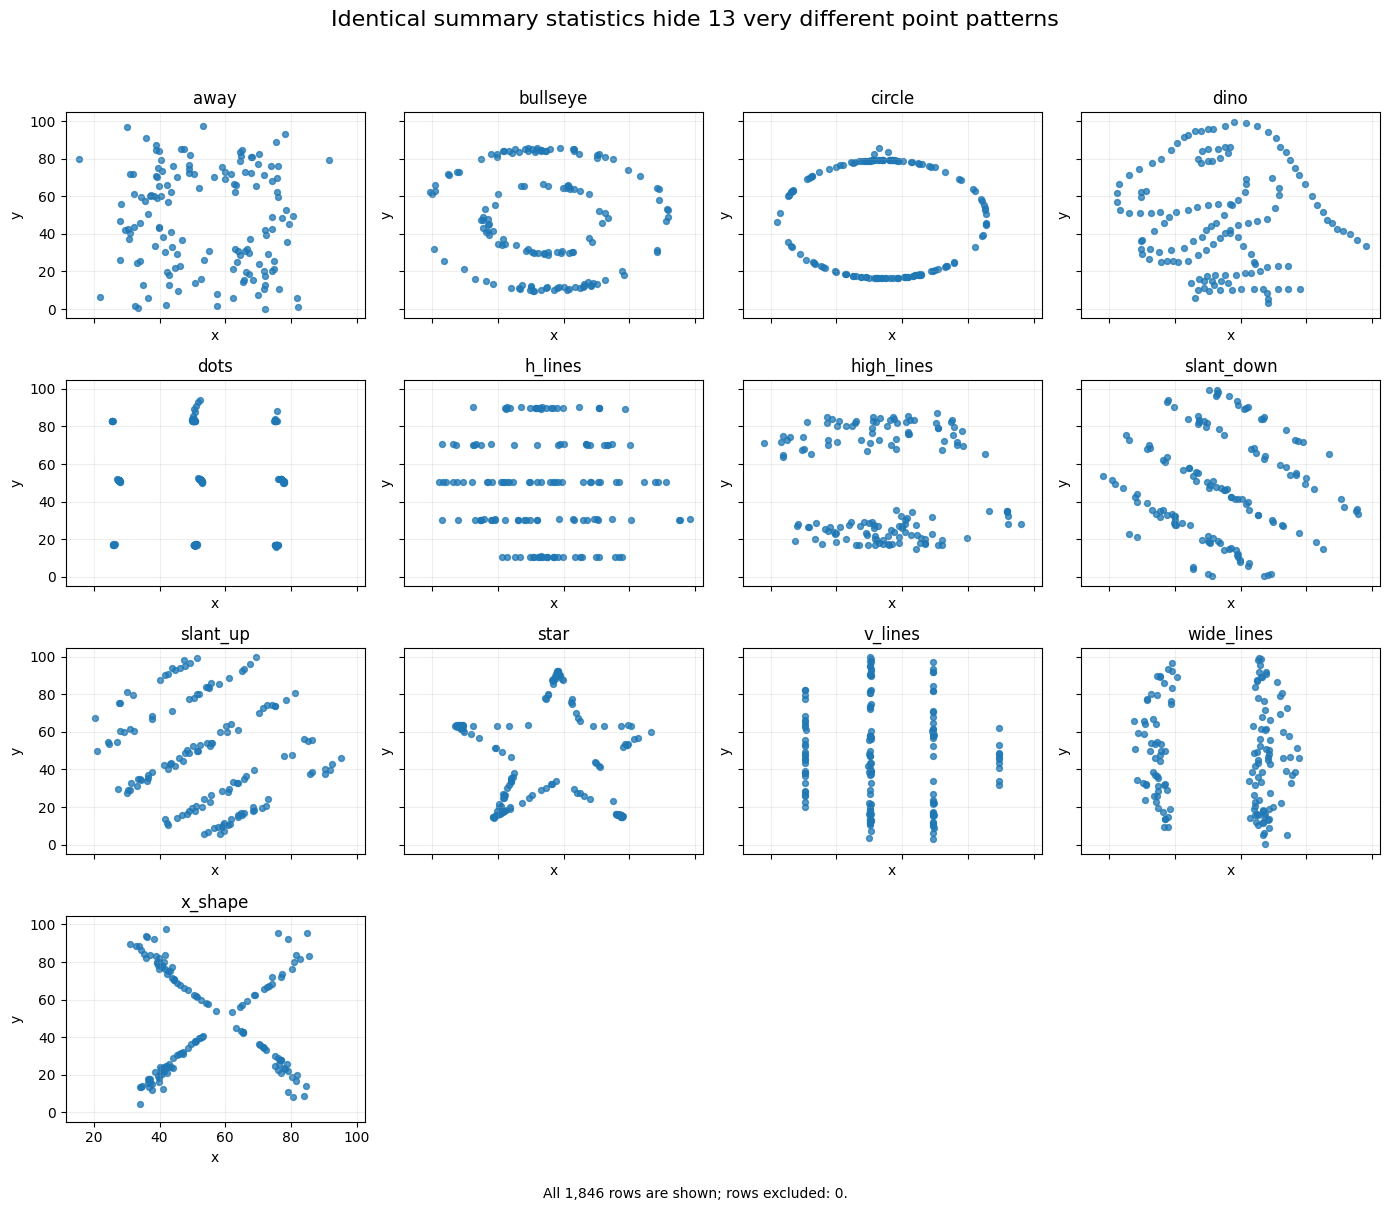

Saved figure to: /home/oai/datasaurus_13_datasets.png


In [4]:
dataset_order = sorted(df['dataset'].unique())

fig, axes = plt.subplots(4, 4, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.ravel()

for i, name in enumerate(dataset_order):
    ax = axes[i]
    subset = df[df['dataset'] == name]
    ax.scatter(subset['x'], subset['y'], s=18, alpha=0.75)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(alpha=0.2)

# Hide the three unused panels.
for ax in axes[len(dataset_order):]:
    ax.axis('off')

fig.suptitle(
    'Identical summary statistics hide 13 very different point patterns',
    fontsize=16,
    y=0.995
)
fig.text(
    0.5, 0.005,
    'All 1,846 rows are shown; rows excluded: 0.',
    ha='center',
    fontsize=10
)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])

plot_path = Path('datasaurus_13_datasets.png')
fig.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved figure to: {plot_path.resolve()}')

## 5. What we actually found

The visualization completely changes the conclusion suggested by the summary table. Although all 13 datasets have nearly identical means, standard deviations, and correlations, their actual distributions are dramatically different. Some form recognizable structures such as a dinosaur, circle, bullseye, star, or X, while others form lines or other distinct arrangements. The summary statistics therefore hide important information about the shape and spatial structure of the data.

This is why visualization is necessary: the same numerical summaries can arise from very different underlying datasets.

## 6. Does having 13 datasets and 142 points each make the summary statistics more trustworthy?

**Not for understanding the overall structure of the data.**

Having 142 observations instead of 11 generally makes estimates such as the mean, standard deviation, and correlation more precise for the particular quantities they measure. However, it does not make those quantities capable of revealing patterns that they were never designed to measure.

The Datasaurus example extends the lesson from Anscombe's four datasets. Even with many more observations and 13 datasets, nearly identical summary statistics can correspond to radically different distributions and shapes.

### Main takeaway

> **Summary statistics are useful, but they should not replace visualization.**

Means tell us about location, standard deviations tell us about spread, and correlation tells us about linear association. None of them, by themselves, tells us what the complete two-dimensional pattern looks like.

## 7. Optional numerical check: how similar are the statistics?

The following calculation reports the range of each summary statistic across the 13 datasets. This makes the similarity visible numerically before we compare it with the scatterplots.

In [5]:
range_check = pd.DataFrame({
    'Minimum': stats[numeric_cols].min(),
    'Maximum': stats[numeric_cols].max(),
    'Range': stats[numeric_cols].max() - stats[numeric_cols].min()
})

display(range_check.round(6))

,Minimum,Maximum,Range
Mean X,54.260150,54.269927,0.009777
Mean Y,47.830252,47.839829,0.009577
SD X,16.760013,16.770000,0.009987
SD Y,26.930002,26.939998,0.009996
Correlation,-0.069446,-0.060341,0.009104


## Final answer in one paragraph

The 13 Datasaurus datasets demonstrate the same fundamental lesson as Anscombe's quartet: numerical summaries alone can conceal major differences in the data. All 13 datasets contain 142 observations and have almost identical means, standard deviations, and correlations, yet their scatterplots reveal very different shapes and structures. Increasing the number of observations makes the calculated statistics more precise, but it does not make those statistics a complete description of the data. Therefore, the larger sample size does **not** eliminate the need for visualization; we should use summary statistics and plots together.